In [1]:
script = False
cluster = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from efficientnet_pytorch import EfficientNet
import joblib

from astropy.io import fits
from astropy.table import Table
from astropy.visualization import make_lupton_rgb

if(script):
    from tqdm import tqdm
else: 
    from tqdm.notebook import tqdm

plt.style.use('dark_background')

# ML Components

In [2]:
num_workers = 0

transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])


In [3]:
class ImageDataset(Dataset):
    """Dataset of Images, Data and Labels"""

    def __init__(self, images, data, labels, transform=None):
        """
        Create a PyTorch dataset from an array of images
		and an array of labels
        """
        super().__init__()
        self.images = images
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        new_image = image.transpose(1,2,0) 
        new_image = (new_image - new_image.min()) / (new_image.max() - new_image.min())
        new_image = Image.fromarray(np.uint8(255*new_image)).convert("RGB")

        label = self.labels[idx]
        
        data_point = self.data.iloc[idx].to_dict()
        sample = {'image': self.transform(new_image), 'label': label, 'img': image, 'data': data_point}
        return sample
    
    def normalize_image(self, image):
        image_g = (image[0]-np.mean(image[0]))/ np.std(image[0])
        image_r = (image[1]-np.mean(image[1]))/ np.std(image[1])
        image_i = (image[2]-np.mean(image[2]))/ np.std(image[2])

        image_g = (image_g-np.min(image_g))/ (np.max(image_g) - np.min(image_g))
        image_r = (image_r-np.min(image_r))/ (np.max(image_r) - np.min(image_r))
        image_i = (image_i-np.min(image_i))/ (np.max(image_i) - np.min(image_i))
        return(image_i, image_r, image_g)


In [4]:
class EfficientNetClass(nn.Module):
    
    def __init__(self, n_classes, pretrained=False):
        super(EfficientNetClass, self).__init__()
        if(not cluster):
            self.model = EfficientNet.from_pretrained('efficientnet-b0',  num_classes=n_classes)
            torch.save(self.model.state_dict(), 'initial_model.pt')
        else:
            self.model = EfficientNet.from_name('efficientnet-b0',  num_classes=n_classes)
            self.model.load_state_dict(torch.load('initial_model.pt'))
            
    def forward(self, x):
        x = self.model(x)
        return x

In [5]:
model = EfficientNetClass(n_classes=14, pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

name = 'Exp/exp4/model_tmp.pt'#'model.pt'#'other.pt' 
model.load_state_dict(torch.load(name, map_location=device, weights_only=True))

Loaded pretrained weights for efficientnet-b0


<All keys matched successfully>

# Util functions

In [6]:
def make_plot_all(images, column_data, Q=9, stretch=40, minimum=(0,0,0)):
    for i in range(len(images)):
        if(i%8 == 0):
            plt.figure(figsize=(12,2))
            for j in range(8):
                if(i+j > len(images)-1): break
                plt.subplot(1,8,j+1)
                title = '{:.2f}'.format(column_data.iloc[i+j])
                plt.title(title)
                rgb = make_lupton_rgb(images[i+j][2], images[i+j][1], images[i+j][0], 
                                    Q=Q, stretch=stretch, minimum=minimum)
                plt.imshow(rgb, aspect='equal')
                plt.xticks([], [])
                plt.yticks([], []) 
            plt.show() 
    plt.close() 


def q_theta_from_e1_e2(e1, e2):
    e = np.sqrt(e1**2 + e2**2)
    q = (1 - e) / (1 + e)
    theta = np.degrees(np.arctan2(e2, e1) / 2)
    return q, theta

# O'Donnell data

All sample:  246
Index(['COADD_OBJECT_ID', 'HPIX_16384', 'HPIX_4096', 'DNF_ZMEAN_SOF', 'RA',
       'DEC', 'FLUX_RADIUS_G', 'FLUX_RADIUS_R', 'FLUX_RADIUS_I',
       'FLUX_RADIUS_Z', 'KRON_RADIUS', 'GAP_FLUX_G', 'MOF_BDF_FLUX_G',
       'MOF_PSF_FLUX_G', 'SOF_BDF_FLUX_G', 'SOF_PSF_FLUX_G', 'MAG_AUTO_G',
       'MAG_APER_4_G', 'MAG_APER_8_G', 'SOF_BDF_G_1', 'SOF_BDF_G_2',
       'IMAFLAGS_ISO_G', 'IMAFLAGS_ISO_R', 'IMAFLAGS_ISO_I', 'IMAFLAGS_ISO_Z',
       'rank', 'num_sources', 'num_lenses', 'mem_match_id', 'einstein_radius',
       'einstein_radius_err', 'ACT', 'BBNA', 'BNA', 'TI', 'RNA', 'RNA2',
       'redM', 'redM_missed', 'SPTPol'],
      dtype='str')


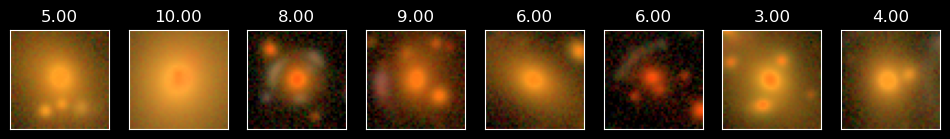

True columns kept:  Index(['einstein_radius', 'einstein_radius_err'], dtype='str')
torch.Size([246, 2])


In [7]:
path_cutouts = '/Users/jimenagonzalez/research/DSPL/Searching-double-lenses/real_lenses/Jack_Y6/'
hdu_list = fits.open(path_cutouts + 'Cutouts/Jack_Y6.fits')
images = hdu_list[1].data.astype(np.float32)
data = Table(hdu_list[2].data).to_pandas()
data = data.drop(['TILENAME'], axis=1)
hdu_list.close()
print('All sample: ', len(data))
print(data.columns)

data_tmp = data.sample(8)
images_tmp = images[data_tmp.index]
make_plot_all(images_tmp, data_tmp['rank'])

labels_dataset = data[['einstein_radius', 'einstein_radius_err']]
print('True columns kept: ', labels_dataset.columns)
labels_dataset = torch.tensor(labels_dataset.values, dtype=torch.float32)
print(labels_dataset.shape)

#dataset = ImageDataset(images, data, np.zeros(len(data), dtype = np.float32), transform=transform)
dataset = ImageDataset(images, data, labels_dataset, transform=transform)
data_loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=1, num_workers=num_workers, shuffle=False)

In [8]:
data.head()

,COADD_OBJECT_ID,HPIX_16384,HPIX_4096,DNF_ZMEAN_SOF,RA,DEC,FLUX_RADIUS_G,FLUX_RADIUS_R,FLUX_RADIUS_I,FLUX_RADIUS_Z,...,einstein_radius_err,ACT,BBNA,BNA,TI,RNA,RNA2,redM,redM_missed,SPTPol
0,1425127607,2261115083,141319692,0.500052,58.176780,-38.429166,9.801247,7.584236,6.131462,5.923448,...,0.432917,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,894391144,3000324340,187520271,0.366919,305.691881,-60.544299,5.247355,5.317457,5.174267,5.466214,...,0.323862,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,977331342,3045780413,190361275,0.304152,342.183210,-44.530832,21.384943,20.261387,19.615810,19.715708,...,0.401137,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1365603963,2211304283,138206517,0.378344,46.067354,-49.357243,11.867730,10.418471,9.992177,9.865899,...,0.953607,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1211759750,2339434891,146214680,0.415800,28.143580,-28.893791,9.686460,9.392047,9.081729,8.964422,...,0.565383,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Evaluating Performance

In [9]:
def testing_analysis(test_loader):
    predicted_data, true_data, complete_data = [], [], []

    for i, sample in enumerate(tqdm(test_loader)):
        data, target, sample_data = sample['image'], sample['label'], sample['data']

        output = model.forward(data)

        predicted_data.append(output.detach().cpu().numpy())
        true_data.append(target.cpu().numpy())
        complete_data.append(pd.DataFrame.from_dict(sample_data).iloc[0])

    scaler_y = joblib.load('Exp/exp4/scaler_y.joblib')

    predicted_data = scaler_y.inverse_transform(np.vstack(predicted_data))
    true_data = np.vstack(true_data)
    complete_data = pd.DataFrame(complete_data).reset_index(drop=True)

    return pd.DataFrame(predicted_data), pd.DataFrame(true_data), complete_data


predicted_data, true_data, complete_data = testing_analysis(data_loader)


  0%|          | 0/246 [00:00<?, ?it/s]

In [10]:
complete_data.head()

,COADD_OBJECT_ID,HPIX_16384,HPIX_4096,DNF_ZMEAN_SOF,RA,DEC,FLUX_RADIUS_G,FLUX_RADIUS_R,FLUX_RADIUS_I,FLUX_RADIUS_Z,...,einstein_radius_err,ACT,BBNA,BNA,TI,RNA,RNA2,redM,redM_missed,SPTPol
0,1.425128e+09,2.261115e+09,141319692.0,0.500052,58.176780,-38.429166,9.801247,7.584236,6.131462,5.923448,...,0.432917,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,8.943911e+08,3.000324e+09,187520271.0,0.366919,305.691881,-60.544299,5.247355,5.317457,5.174267,5.466214,...,0.323862,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,9.773313e+08,3.045780e+09,190361275.0,0.304152,342.183210,-44.530832,21.384943,20.261387,19.615810,19.715708,...,0.401137,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.365604e+09,2.211304e+09,138206517.0,0.378344,46.067354,-49.357243,11.867730,10.418471,9.992177,9.865899,...,0.953607,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.211760e+09,2.339435e+09,146214680.0,0.415800,28.143580,-28.893791,9.686460,9.392047,9.081729,8.964422,...,0.565383,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [11]:
# Formatting predicted and true dataframes
names = ['EINSTEIN_RADIUS', 'e1_lens', 'e2_lens', 'center_x_lens', 'center_y_lens', 'R_sersic_source_light',
       'n_sersic_source_light', 'e1_source_light', 'e2_source_light', 'center_x_source', 'center_y_source', 
        'R_sersic_lens_light', 'e1_lens_light', 'e2_lens_light']
column_mapping = {old_column: new_column for old_column, new_column in enumerate(names)}
predicted_data.rename(columns=column_mapping, inplace=True)

names = ['einstein_radius', 'einstein_radius_err']
column_mapping = {old_column: new_column for old_column, new_column in enumerate(names)}
true_data.rename(columns=column_mapping, inplace=True)

true_data.head()

,einstein_radius,einstein_radius_err
0,3.179565,0.432917
1,7.660364,0.323862
2,32.510639,0.401137
3,25.418392,0.953607
4,16.423428,0.565383


In [12]:
predicted_data.head()

,EINSTEIN_RADIUS,e1_lens,e2_lens,center_x_lens,center_y_lens,R_sersic_source_light,n_sersic_source_light,e1_source_light,e2_source_light,center_x_source,center_y_source,R_sersic_lens_light,e1_lens_light,e2_lens_light
0,3.720319,0.121646,-0.045972,0.000929,0.001160,0.828692,3.416224,0.034636,0.050884,0.027064,-0.057835,1.362041,0.068297,-0.002945
1,3.888131,0.121257,-0.039736,0.000413,0.001144,0.851681,3.630608,0.041378,-0.059677,0.110767,0.285043,1.605212,0.028061,-0.013252
2,3.407278,0.102740,0.035583,0.000179,0.000823,0.840724,3.149492,0.080300,-0.079751,0.084040,-0.226177,1.534939,0.009374,-0.033522
3,3.984132,0.075138,0.070157,0.000948,-0.000533,0.804542,3.335263,0.050745,-0.043606,0.232778,0.093281,1.532278,0.029729,0.005579
4,3.483377,0.029042,-0.034287,0.000811,0.000615,0.861201,3.651305,-0.092410,0.015269,0.059042,0.100161,1.438550,0.033818,0.002700


/var/folders/kn/2ng47p4x5qq6hwt5vqw16gfh0000gn/T/ipykernel_62992/2395267516.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_tmp = complete_data[complete_data['einstein_radius'] < 8][complete_data['rank'] > 5]


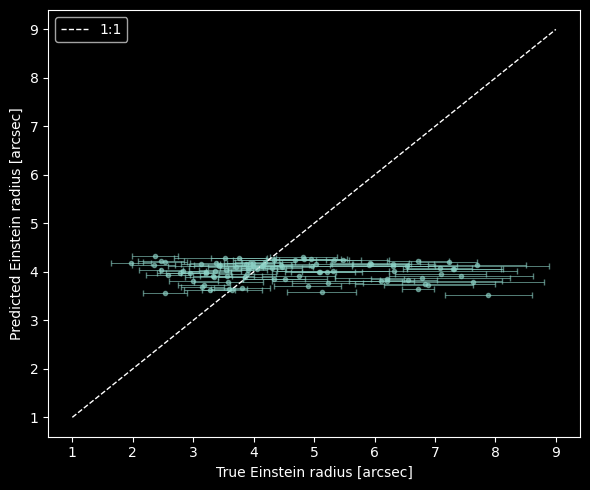

In [13]:
#Cleaning data: rank & Einstein radius -> Get index
data_tmp = complete_data[complete_data['einstein_radius'] < 8][complete_data['rank'] > 5]
idx = data_tmp.index 

plt.figure(figsize=(6, 5))
plt.errorbar(true_data.iloc[idx]['einstein_radius'], predicted_data.iloc[idx]['EINSTEIN_RADIUS'], xerr=true_data.iloc[idx]['einstein_radius_err'], fmt='o', ms=3, 
             elinewidth=0.7, capsize=2, alpha=0.6)
line = np.linspace(1, 9, 10)
plt.plot(line, line, 'w--', linewidth=1, label='1:1')
plt.xlabel('True Einstein radius [arcsec]')
plt.ylabel('Predicted Einstein radius [arcsec]')
plt.legend()
plt.tight_layout()
plt.show()